## Processing thematic coding data from the corpus of African youth literature

### Introduction

This Python notebook is a supportive guide for thematic analysis in the dissertation. It is split into two parts, the first focusing on major themes and the second on sub-themes. 

**Part I: Calculating the hermenumerical indicators for themes** presents data on the themes identified in a corpus of African youth literature. Themes were coded across texts using ATLAS.ti, enabling mixed-methods evaluation. There are 15 themes, which represent groups of related sub-themes. The purpose is to gain an understanding of the overall thematic structure of the corpus and identify the most common major themes. Four hermenumerical indicators – thematic frequency, thematic weight, thematic salience, and thematic density – are calculated to provide insights into how themes are distributed and emphasised in the corpus. Diagrams are produced to illustrate the results and these are presented in Chapter 4.

**Part II: Tracking sub-themes in the corpus** presents data on the occurrence of the sub-themes under each major theme. There are 121 sub-themes under the 15 major themes. The purpose is to identify the most common sub-themes in the corpus. A diagram is produced to illustrate the results.

All the raw data used in this notebook is contained in an Excel spreadsheet available from GitHub at: https://github.com/BronwynBowlesKing/African-youth-literature-corpus-analysis. This spreadsheet ('combined_coding_record.xlsx') contains the coding data for the major themes as well as for the sub-themes.

## Part I: Calculating the hermenumerical indicators for themes

The process followed below involves loading the dataset, calculation of theme statistics, and the production of summary tables and visualisations. These analyses help reveal thematic patterns, supporting a better understanding of the issues reflected in the literature under study. 

### Step 0. Preparation

#### 0.1 Install packages and modules

If needed, these packages and modules can be installed or downloaded. This is best done in the terminal with the code below rather than directly in the notebook. 

In [1]:
# pip install numpy pandas matplotlib seaborn openpyxl plotly

#### 0.2 Load packages and modules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)  # To render plotly figures
# openpyxl must be installed to work with Excel spreadsheets, but does not need to be imported

#### 0.3 Define functions

Functions to count individual themes and sub-themes and to display tables neatly are defined below.

In [3]:
def td_count(df, theme_cols, salience_col='thematic_salience'):
    '''
    Counts 1s in theme cols for each row to calculate thematic density, 
    adds a col 'thematic_density_n' with these counts, and inserts column 
    to df for each genre.
    '''

    # Calculate the sum for each row
    df['thematic_density_n'] = df[theme_cols].sum(axis=1)

    # Find thematic_salience column and add new data
    salience_pos = df.columns.get_loc(salience_col)

    cols = list(df.columns)
    cols.remove('thematic_density_n')
    cols.insert(salience_pos, 'thematic_density_n')

    return df[cols]


def count_distinct(row):
    '''
    Function splits text ids by comma and converts them to integers. 
    Distinct text ids are then counted to arrive at the total number of 
    times a sub-theme appears in the corpus.
    '''
    ids = []
    for col in ['poetry', 'stories', 'plays']:
        cell = row[col]
        if pd.notna(cell):
            ids += [int(x.strip()) for x in str(cell).split(',') if x.strip().isdigit()]
    return len(set(ids))


def display_table(df, caption, color="#000000D3", alignment='center'):
    '''
    Displays key df as styled tables with headings. Drops index column.
    Numbers are shown to two decimal places.

    Parameters:
    - df (pd.DataFrame): dataframe to display
    - caption (str): Header text above the table
    - color (str): Colour for the caption 
    - alignment (str): Text alignment for headers and cells ('center', 'left', 'right')
    '''
    styles = [
        dict(selector='caption', props=[('font-weight', 'bold'), ('color', color)]),
        dict(selector='th', props=[('text-align', alignment)]),
        dict(selector='td', props=[('text-align', alignment)])
    ]
    
    display(
        df.style
            .format(precision=2)
            .hide(axis='index')
            .set_caption(caption)
            .set_table_styles(styles)
    )

#### 0.4 Load coding records

The coding records are loaded into memory and converted into Python dataframes (dfs) (structured tables for computational analysis) by genre. The records are raw data with multi-hot coding in which 1 indicates that a major theme was identified and 0 indicates that it was not. Each text is identified by its title and an id number. To preview the raw data structure, the first five rows of each df are shown below as there are 155 in total.

In [4]:
sheets = ['poetry_codes', 'stories_codes', 'plays_codes']
dfs = pd.read_excel('combined_coding_record.xlsx', sheet_name=sheets, engine='openpyxl')

# Raw dfs kept separate for calculations 
raw_poetry_df = dfs['poetry_codes'].copy()
raw_stories_df = dfs['stories_codes'].copy()
raw_plays_df = dfs['plays_codes'].copy()

display_table(raw_poetry_df.head(), 'Table 1: Poetry dataframe (row 1–5)')
display_table(raw_stories_df.head(), 'Table 2: Short stories dataframe (row 1–5)')
display_table(raw_plays_df.head(), 'Table 3: Plays dataframe (row 1–5)')

id,title,A,B,E,F,G,H,L,N,O,P,R,S,T,V,Y,thematic_salience
1,The Agenda is to Rise,0,0,0,1,1,0,0,0,0,0,0,1,1,1,1,G
2,The Often Disguised Gift of Hope,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,Y
3,Johannesburg An Ode,0,0,1,0,0,0,0,0,1,1,0,1,0,1,1,E
9,Candlelight,0,0,1,1,0,0,0,0,0,0,0,0,0,1,1,Y
10,Eternal bug,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,O


id,title,A,B,E,F,G,H,L,N,O,P,R,S,T,V,Y,thematic_salience
34,Katherine,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,Y
35,Tonight Janny is smiling,0,0,1,1,1,0,0,0,0,0,1,1,0,0,1,F
36,Khosi What is a Man,0,0,1,1,1,1,0,0,1,1,1,1,1,1,1,Y
37,The Ancestors Cry,1,1,1,1,1,1,0,1,1,1,0,1,1,1,1,B
38,When the sun is up,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,Y


id,title,A,B,E,F,G,H,L,N,O,P,R,S,T,V,Y,thematic_salience
48,Yenzokuhle,0,1,1,1,1,1,0,0,1,1,1,1,0,1,1,Y
93,Like Hamlet,1,0,0,1,1,1,0,0,1,0,1,1,0,1,1,R
94,Babazile,0,1,1,1,1,1,1,0,0,1,1,1,1,1,1,S
145,Thula Mntanam,1,1,1,1,1,1,0,0,0,1,0,1,1,1,1,P
146,Come By Here,0,1,0,1,1,0,0,1,0,0,0,0,0,0,0,N


### Step 1. Define key variables

The number of texts in each genre and the whole corpus are set as variables below. The codes for each of the 15 major themes are listed and mapped to their full names. This data will be called in code blocks later in the notebook.

In [5]:
# Corpus and genre text counts
poetry_count = 117
stories_count = 31
plays_count = 7
corpus_count = 155

# Theme codes and mapping
theme_cols = ['A', 'B', 'E', 'F', 'G', 'H', 'L', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'Y']

theme_map = {
    'A': 'Arts and Culture',
    'B': 'Beliefs',
    'E': 'Environment',
    'G': 'Gender',
    'F': 'Family',
    'H': 'Health',
    'L': 'LGBTQIA',
    'N': 'Nature and Science',
    'O': 'Humanity',
    'P': 'Postcolonial',
    'R': 'Relationships',
    'S': 'Society',
    'T': 'Tradition',
    'V': 'Violation',
    'Y': 'Youth'
}

### Step 2. Calculate hermenumerical indicators

#### 2.1 Thematic frequency

This step covers the first hermenumerical indicator, thematic frequency, which shows how common a theme is in the corpus. Thematic frequency (*TF*) for a theme (*k*) is calculated as the number of texts (${n_k}$) featuring a theme, divided by the total number of texts (*c*), multiplied by 100. Texts often show indications of a certain theme several times, such as aspects of the Postcolonial theme identified at different points in the same short story. However, once identified, a theme is counted only once for a given text and this data is used for all calculations.

$
\text{TF}_k = \frac{n_k}{c} \times 100
$

TF is calculated below by theme for the three genres and then for the whole corpus. The results are sorted in descending order and displayed in tables. In Table 4: Poetry thematic frequency below, for example, the major theme with the highest thematic frequency is Youth (Y), which is to be expected for a corpus of youth literature. Youth-related issues are referenced in 93 poems or 79.49%. The rest of the tables below in this section show the thematic frequency results for short stories, plays, and then for the whole corpus. 

In [6]:
# Poetry TF
poetry_tf_n = raw_poetry_df[theme_cols].sum()
poetry_tf_percent = (poetry_tf_n / poetry_count) * 100

poetry_tf_df = pd.DataFrame({
    'theme_code': theme_cols,
    'poetry_tf_n': poetry_tf_n.values,
    'poetry_tf_%': poetry_tf_percent.values
})

poetry_tf_df = poetry_tf_df.sort_values(by='poetry_tf_%', ascending=False)
poetry_tf_df.reset_index(drop=True, inplace=True)

display_table(poetry_tf_df, 'Table 4: Poetry thematic frequency')

theme_code,poetry_tf_n,poetry_tf_%
Y,93,79.49
O,65,55.56
S,63,53.85
V,51,43.59
P,39,33.33
G,37,31.62
R,31,26.50
B,28,23.93
A,24,20.51
H,24,20.51


In [7]:
# Short stories TF
stories_tf_n = raw_stories_df[theme_cols].sum()
stories_tf_percent = (stories_tf_n / stories_count) * 100

stories_tf_df = pd.DataFrame({
    'theme_code': theme_cols,
    'stories_tf_n': stories_tf_n.values,
    'stories_tf_%': stories_tf_percent.values
})

stories_tf_df = stories_tf_df.sort_values(by='stories_tf_%', ascending=False)
stories_tf_df.reset_index(drop=True, inplace=True)

display_table(stories_tf_df, 'Table 5: Short stories thematic frequency')

theme_code,stories_tf_n,stories_tf_%
Y,28,90.32
F,27,87.10
S,26,83.87
G,23,74.19
O,21,67.74
R,21,67.74
E,20,64.52
V,20,64.52
H,17,54.84
T,16,51.61


In [8]:
# Plays TF
plays_tf_n = raw_plays_df[theme_cols].sum()
plays_tf_percent = (plays_tf_n / plays_count) * 100

plays_tf_df = pd.DataFrame({
    'theme_code': theme_cols,
    'plays_tf_n': plays_tf_n.values,
    'plays_tf_%': plays_tf_percent.values
})

plays_tf_df = plays_tf_df.sort_values(by='plays_tf_%', ascending=False)
plays_tf_df.reset_index(drop=True, inplace=True)

display_table(plays_tf_df, 'Table 6: Plays thematic frequency')

theme_code,plays_tf_n,plays_tf_%
F,7,100.00
G,7,100.00
B,6,85.71
H,6,85.71
V,5,71.43
Y,5,71.43
R,5,71.43
S,5,71.43
O,4,57.14
E,4,57.14


In [9]:
# Corpus TF
corpus_tf_n = poetry_tf_n + stories_tf_n + plays_tf_n

corpus_tf_percent = (corpus_tf_n / corpus_count) * 100

corpus_tf_df = pd.DataFrame({
    'theme_code': theme_cols,
    'corpus_tf_n': corpus_tf_n.values,
    'corpus_tf_%': corpus_tf_percent.values
})

corpus_tf_df = corpus_tf_df.sort_values(by='corpus_tf_%', ascending=False)
corpus_tf_df.reset_index(drop=True, inplace=True)

display_table(corpus_tf_df, 'Table 7: Corpus thematic frequency')

theme_code,corpus_tf_n,corpus_tf_%
Y,126,81.29
S,94,60.65
O,90,58.06
V,76,49.03
G,67,43.23
R,57,36.77
F,55,35.48
P,55,35.48
B,49,31.61
E,48,30.97


#### 2.2 Thematic weight

This hermenumerical indicator shows how often a theme was counted compared to all other themes, as a comparative or weighted measure. Thematic weight (*TW*) is calculated as the number of times a theme was coded (${n_k}$), divided by the total number of theme codings in the corpus (*g*), multiplied by 100.

$
\text{TW}_k = \frac{n_k}{g} \times 100
$

TW is calculated below by theme for the three genres, and then for the whole corpus. In Table 8: Poetry thematic weight below, for example, the thematic weight is highest for the Youth theme, accounting for 17.61% of all the themes identified in the poetry.

In [10]:
# Poetry TW
poetry_total_codes = poetry_tf_n.sum()
poetry_tw_percent = (poetry_tf_n / poetry_total_codes) * 100

poetry_tw_df = pd.DataFrame({
    'theme_code': theme_cols,
    'poetry_tw_%': poetry_tw_percent.values
})

poetry_tw_df = poetry_tw_df.sort_values(by='poetry_tw_%', ascending=False)
poetry_tw_df.reset_index(drop=True, inplace=True)

display_table(poetry_tw_df, 'Table 8: Poetry thematic weight')

theme_code,poetry_tw_%
Y,17.61
O,12.31
S,11.93
V,9.66
P,7.39
G,7.01
R,5.87
B,5.30
A,4.55
H,4.55


In [11]:
# Short stories TW
stories_total_codings = stories_tf_n.sum()
stories_tw_percent = (stories_tf_n / stories_total_codings) * 100

stories_tw_df = pd.DataFrame({
    'theme_code': theme_cols,
    'stories_tw_%': stories_tw_percent.values
})

stories_tw_df = stories_tw_df.sort_values(by='stories_tw_%', ascending=False)
stories_tw_df.reset_index(drop=True, inplace=True)

display_table(stories_tw_df, 'Table 9: Short stories thematic weight')

theme_code,stories_tw_%
Y,10.49
F,10.11
S,9.74
G,8.61
O,7.87
R,7.87
E,7.49
V,7.49
H,6.37
T,5.99


In [12]:
# Plays TW
plays_total_codings = plays_tf_n.sum()
plays_tw_percent = (plays_tf_n / plays_total_codings) * 100

plays_tw_df = pd.DataFrame({
    'theme_code': theme_cols,
    'plays_tw_%': plays_tw_percent.values
})

plays_tw_df = plays_tw_df.sort_values(by='plays_tw_%', ascending=False)
plays_tw_df.reset_index(drop=True, inplace=True)

display_table(plays_tw_df, 'Table 10: Plays thematic weight')

theme_code,plays_tw_%
F,10.45
G,10.45
B,8.96
H,8.96
V,7.46
Y,7.46
R,7.46
S,7.46
O,5.97
E,5.97


In [13]:
# Corpus TW
corpus_tf_n = poetry_tf_n + stories_tf_n + plays_tf_n

corpus_total_codings = corpus_tf_n.sum()
corpus_tw_percent = (corpus_tf_n / corpus_total_codings) * 100

corpus_tw_df = pd.DataFrame({
    'theme_code': theme_cols,
    'corpus_tw_%': corpus_tw_percent.values
})

corpus_tw_df = corpus_tw_df.sort_values(by='corpus_tw_%', ascending=False)
corpus_tw_df.reset_index(drop=True, inplace=True)

display_table(corpus_tw_df, 'Table 11: Corpus thematic weight')

theme_code,corpus_tw_%
Y,14.62
S,10.90
O,10.44
V,8.82
G,7.77
R,6.61
F,6.38
P,6.38
B,5.68
E,5.57


#### 2.3 Thematic salience

A single theme was identified as the most salient (most important or prominent) for each text based on a consideration of literary elements in the text. Thematic salience (*TS*) is calculated as the number of times a salient theme (${s_k}$) was counted, divided by the total number of texts (*c*), multiplied by 100.

$
\text{TS}_k = \frac{s_k}{c} \times 100
$

TS is calculated for the three genres and then for the whole corpus. Table 12: Poetry thematic salience shows that the thematic salience is highest in the poetry genre for the Humanity (O) theme. It is the most salient theme in 25 poems or 21.37% of the poetry. 

In [14]:
# Poetry TS
poetry_ts_counts = raw_poetry_df['thematic_salience'].value_counts()
poetry_ts_counts = poetry_ts_counts.reindex(theme_cols, fill_value=0)

poetry_ts_percent = (poetry_ts_counts / poetry_count) * 100

poetry_ts_df = pd.DataFrame({
    'theme': theme_cols,
    'poetry_ts_n': poetry_ts_counts.values,
    'poetry_ts_%' : poetry_ts_percent
}).reset_index(drop=True)

poetry_ts_df = poetry_ts_df.sort_values(by='poetry_ts_%', ascending=False)
poetry_ts_df.reset_index(drop=True, inplace=True)

display_table(poetry_ts_df, 'Table 12: Poetry thematic salience')

theme,poetry_ts_n,poetry_ts_%
O,25,21.37
V,15,12.82
G,14,11.97
Y,14,11.97
R,13,11.11
P,11,9.40
H,5,4.27
A,4,3.42
F,4,3.42
E,4,3.42


In [15]:
# Stories TS
stories_ts_counts = raw_stories_df['thematic_salience'].value_counts()
stories_ts_counts = stories_ts_counts.reindex(theme_cols, fill_value=0)

stories_ts_percent = (stories_ts_counts / stories_count) * 100

stories_ts_df = pd.DataFrame({
    'theme': theme_cols,
    'stories_ts_n': stories_ts_counts.values,
    'stories_ts_%' : stories_ts_percent
}).reset_index(drop=True)

stories_ts_df = stories_ts_df.sort_values(by='stories_ts_%', ascending=False)
stories_ts_df.reset_index(drop=True, inplace=True)

display_table(stories_ts_df, 'Table 13: Short stories thematic salience')

theme,stories_ts_n,stories_ts_%
Y,10,32.26
F,7,22.58
L,5,16.13
G,3,9.68
V,2,6.45
B,1,3.23
H,1,3.23
R,1,3.23
P,1,3.23
A,0,0.00


In [16]:
# Plays TS
plays_ts_counts = raw_plays_df['thematic_salience'].value_counts()
plays_ts_counts = plays_ts_counts.reindex(theme_cols, fill_value=0)

plays_ts_percent = (plays_ts_counts / plays_count) * 100

plays_ts_df = pd.DataFrame({
    'theme': theme_cols,
    'plays_ts_n': plays_ts_counts.values,
    'plays_ts_%' : plays_ts_percent
    
}).reset_index(drop=True)

plays_ts_df = plays_ts_df.sort_values(by='plays_ts_%', ascending=False)
plays_ts_df.reset_index(drop=True, inplace=True)

display_table(plays_ts_df, 'Table 14: Plays thematic salience')

theme,plays_ts_n,plays_ts_%
G,2,28.57
P,1,14.29
Y,1,14.29
S,1,14.29
R,1,14.29
N,1,14.29
B,0,0.00
L,0,0.00
H,0,0.00
F,0,0.00


In [17]:
# Corpus TS
corpus_ts_counts = poetry_ts_counts + stories_ts_counts + plays_ts_counts
corpus_ts_counts = corpus_ts_counts.reindex(theme_cols, fill_value=0)

corpus_ts_percent = (corpus_ts_counts / corpus_count) * 100

corpus_ts_df = pd.DataFrame({
    'theme': theme_cols,
    'corpus_ts_n': corpus_ts_counts.values,
    'corpus_ts_%' : corpus_ts_percent
    
}).reset_index(drop=True)

corpus_ts_df = corpus_ts_df.sort_values(by='corpus_ts_%', ascending=False)
corpus_ts_df.reset_index(drop=True, inplace=True)

display_table(corpus_ts_df, 'Table 15: Corpus thematic salience')

theme,corpus_ts_n,corpus_ts_%
O,25,16.13
Y,25,16.13
G,19,12.26
V,17,10.97
R,15,9.68
P,13,8.39
F,11,7.10
H,6,3.87
L,6,3.87
A,4,2.58


#### 2.4 Thematic density

Thematic density (*TD*) is simply a count of all the major themes identified for a single text (${k_n}$). 

$
\text{TD} = \ k_{1} + k_{2} + k_{3} ...
$

TD is calculated below for each text in batches by genre. The texts are then ranked by their thematic density in descending order. In the last column of the tables, the thematic density for an individual text is shown. Only the first few records are shown below, as there 155 in total, but more can be displayed by changing the value in the .head() method or by removing it to view them all.

In Table 16: Poetry thematic density by text, we can see that the poem 'Tales at the River' has the highest thematic density (13 major themes). This indicates that the poem manages to incorporate a wide variety of issues, making it thematically dense.

In [18]:
# Poetry TD
poetry_td_df = td_count(raw_poetry_df, theme_cols)
poetry_td_df = poetry_td_df.sort_values(by='thematic_density_n', ascending=False)
poetry_td_df.reset_index(drop=True, inplace=True)

display_table(poetry_td_df.head().drop(columns=['thematic_salience']), 'Table 16: Poetry thematic density by text (row 1–5)')

id,title,A,B,E,F,G,H,L,N,O,P,R,S,T,V,Y,thematic_density_n
54,Tales at the River,1,1,0,1,1,1,1,1,1,1,0,1,1,1,1,13
119,Kibera,0,0,1,1,0,1,0,1,0,1,0,1,0,1,1,8
154,South Africa,0,1,1,1,0,1,0,0,0,1,0,1,0,1,1,8
104,I have the fire,0,0,0,0,0,1,0,0,1,1,1,1,1,1,1,8
81,5030,0,0,1,0,0,1,0,0,1,1,0,1,0,1,1,7


In [19]:
# Short stories TD
stories_td_df = td_count(raw_stories_df, theme_cols)
stories_td_df = stories_td_df.sort_values(by='thematic_density_n', ascending=False)
stories_td_df.reset_index(drop=True, inplace=True)

display_table(stories_td_df.head().drop(columns=['thematic_salience']), 'Table 17: Short stories thematic density by text (row 1–5)')

id,title,A,B,E,F,G,H,L,N,O,P,R,S,T,V,Y,thematic_density_n
37,The Ancestors Cry,1,1,1,1,1,1,0,1,1,1,0,1,1,1,1,13
40,The Poem of 99 Sunset Road,1,1,1,1,1,1,0,1,1,1,1,1,0,1,1,13
141,Millennium Children,1,1,1,1,1,1,1,0,1,0,1,1,1,1,1,13
161,The Girl Who Played Rede,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,13
43,Blessings,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1,12


In [20]:
# Plays TD
plays_td_df = td_count(raw_plays_df, theme_cols)
plays_td_df = plays_td_df.sort_values(by='thematic_density_n', ascending=False)
plays_td_df.reset_index(drop=True, inplace=True)

display_table(plays_td_df.head().drop(columns=['thematic_salience']), 'Table 18: Plays thematic density by text (row 1–5)')

id,title,A,B,E,F,G,H,L,N,O,P,R,S,T,V,Y,thematic_density_n
94,Babazile,0,1,1,1,1,1,1,0,0,1,1,1,1,1,1,12
48,Yenzokuhle,0,1,1,1,1,1,0,0,1,1,1,1,0,1,1,11
145,Thula Mntanam,1,1,1,1,1,1,0,0,0,1,0,1,1,1,1,11
194,Vashti,0,1,0,1,1,1,0,0,1,1,1,1,1,1,0,10
168,Girl,0,1,1,1,1,1,0,1,1,0,1,0,1,0,1,10


#### 2.4.1 Descriptive statistics for thematic density

Below, the mean (average), minimum, maximum and standard deviation (std) values are calculated for thematic density in the poetry. This process is repeated for the other two genres and the corpus. Standard deviation is a measure of variation or spread in a data set. A lower standard deviation means that the data points tend to be very close to the mean, while a higher standard deviation indicates that the data points are spread out over a wider range of values.  

In some cases, the mean is closer to the minimum and the standard deviation is lower, as in the case of the poetry here. In other cases, the mean is closer to the maximum and the standard deviation is higher, as in the case of the short stories and plays. This indicates how much variety in thematic density there generally is in a genre and the corpus overall.

In [21]:
# Calculate TD statistics by genre
poetry_stats = poetry_td_df['thematic_density_n'].agg(['min', 'mean', 'max', 'std'])
stories_stats = stories_td_df['thematic_density_n'].agg(['min', 'mean', 'max', 'std'])
plays_stats = plays_td_df['thematic_density_n'].agg(['min', 'mean', 'max', 'std'])

# Corpus
corpus_density = pd.concat([
    poetry_td_df['thematic_density_n'],
    stories_td_df['thematic_density_n'],
    plays_td_df['thematic_density_n']
])
corpus_stats = corpus_density.agg(['min', 'mean', 'max', 'std'])

# Create new df
thematic_density_df = pd.DataFrame({
    'genre': ['poetry', 'stories', 'plays', 'corpus'],
    'min': [poetry_stats['min'], stories_stats['min'], plays_stats['min'], corpus_stats['min']],
    'mean': [
        round(poetry_stats['mean'], 4),
        round(stories_stats['mean'], 4),
        round(plays_stats['mean'], 4),
        round(corpus_stats['mean'], 4)
    ],
    'max': [poetry_stats['max'], stories_stats['max'], plays_stats['max'], corpus_stats['max']],
    'std': [poetry_stats['std'], stories_stats['std'], plays_stats['std'], corpus_stats['std']]
})

display_table(thematic_density_df, 'Table 19: Thematic density descriptive stats')

genre,min,mean,max,std
poetry,2.00,4.51,13.00,1.61
stories,2.00,8.61,13.00,2.96
plays,4.00,9.57,12.00,2.64
corpus,2.00,5.56,13.00,2.71


### Step 3. Visualise the hermenumerical results 

#### 3.1 Compare corpus thematic frequency, thematic weight and thematic salience

A table of aggregate results for the whole corpus for thematic frequency, thematic weight and thematic salience is created and saved below. Code is provided to illustrate the data using bar graphs for each of these hermenumerical indicators. The graphs are not rendered in this notebook again as they are presented in the dissertation in Chapter 4, section 4.2 and 4.4.

In [22]:
merged_df = (
    corpus_tf_df
    .merge(corpus_tw_df, on='theme_code')
    .merge(corpus_ts_df, left_on='theme_code', right_on='theme')
)
merged_df['theme_name'] = merged_df['theme_code'].map(theme_map)

merged_df = merged_df[['theme_code', 'theme_name', 'corpus_tf_%', 'corpus_tw_%', 'corpus_ts_%']]

display_table(merged_df, 'Table 20: Combined corpus thematic frequency, weight, and salience results')

theme_code,theme_name,corpus_tf_%,corpus_tw_%,corpus_ts_%
Y,Youth,81.29,14.62,16.13
S,Society,60.65,10.90,1.94
O,Humanity,58.06,10.44,16.13
V,Violation,49.03,8.82,10.97
G,Gender,43.23,7.77,12.26
R,Relationships,36.77,6.61,9.68
F,Family,35.48,6.38,7.10
P,Postcolonial,35.48,6.38,8.39
B,Beliefs,31.61,5.68,1.94
E,Environment,30.97,5.57,2.58


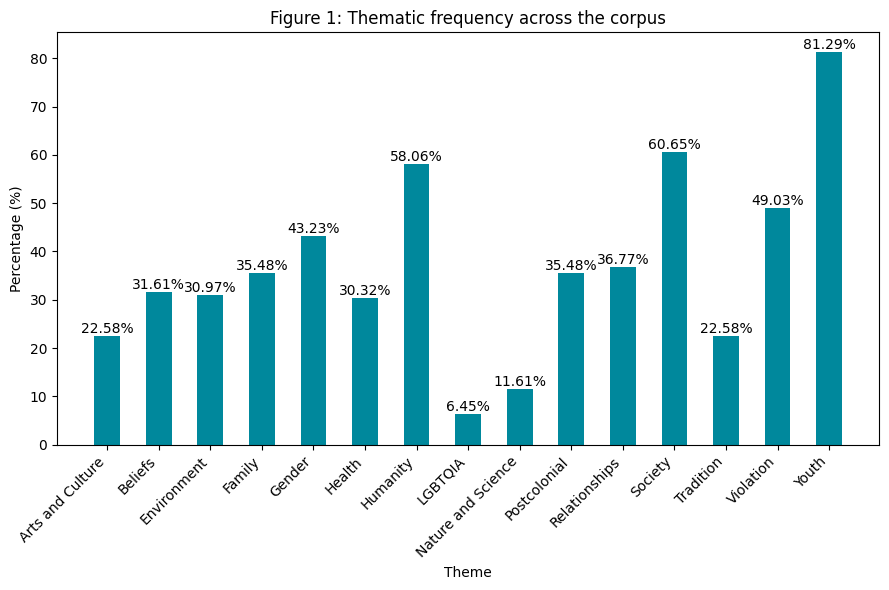

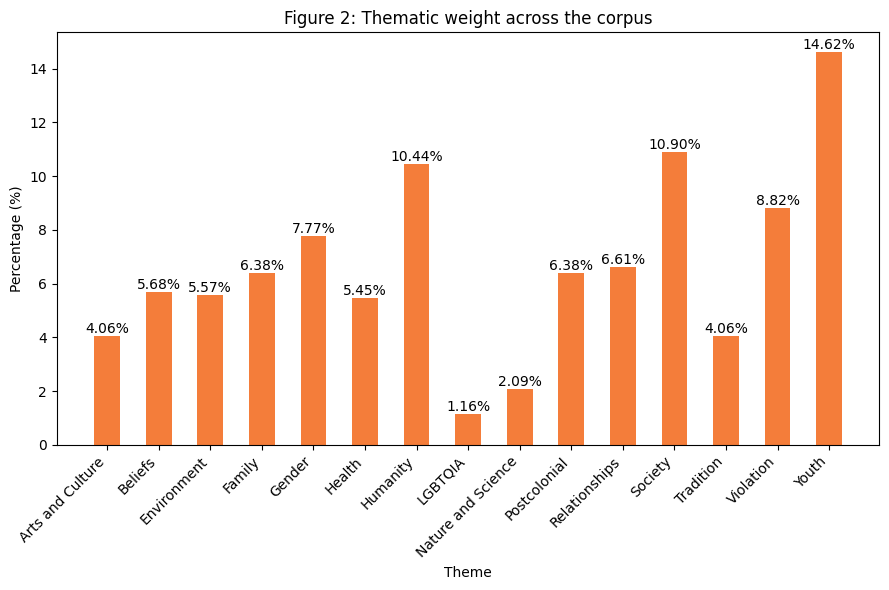

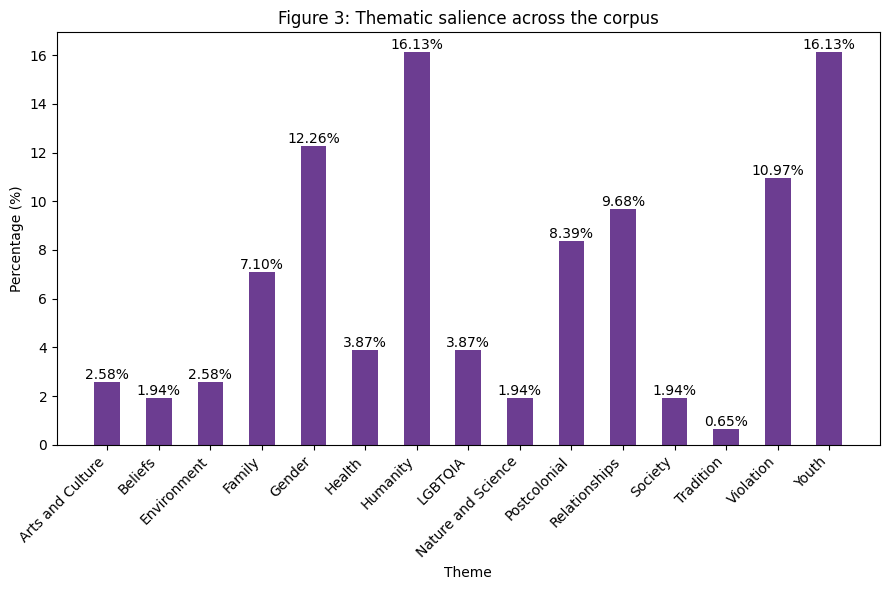

In [23]:
merged_df = merged_df.sort_values(by='theme_name')
index = np.arange(len(merged_df))
bar_width = 0.5

# Thematic frequency
plt.figure(figsize=(9, 6))
bars = plt.bar(index, merged_df['corpus_tf_%'], bar_width, color='#00889C')
plt.title('Figure 1: Thematic frequency across the corpus')  
plt.xlabel('Theme')
plt.ylabel('Percentage (%)')
plt.xticks(index, merged_df['theme_name'], rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('thematic_frequency.png')
plt.show()

# Thematic weight
plt.figure(figsize=(9, 6))
bars = plt.bar(index, merged_df['corpus_tw_%'], bar_width, color='#f47d3a')
plt.title('Figure 2: Thematic weight across the corpus')
plt.xlabel('Theme')
plt.ylabel('Percentage (%)')
plt.xticks(index, merged_df['theme_name'], rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('thematic_weight.png')
plt.show()

# Thematic salience
plt.figure(figsize=(9, 6))
bars = plt.bar(index, merged_df['corpus_ts_%'], bar_width, color='#6c3d91')
plt.title('Figure 3: Thematic salience across the corpus')
plt.xlabel('Theme')
plt.ylabel('Percentage (%)')
plt.xticks(index, merged_df['theme_name'], rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('thematic_salience.png')
plt.show()

## Part II: Tracking sub-themes in the corpus

This part of the notebook presents data on the 121 sub-themes recorded in the corpus. The program takes the raw data from a spreadsheet and calculates the frequency of each sub-theme. The results are ranked in descending order and presented in a table. 

Note that for the purposes of plotting diagrams, the names of some of sub-themes have been shortened. For example, 'Romantic/sexual' refers to 'Relationships of a romantic and sexual nature'.

#### Step 4. Load sub-theme records

In [24]:
# Load spreadsheets
sheets = [
    'Arts and Culture', 'Beliefs', 'Environment', 
    'Gender', 'Family', 'Health', 
    'LGBTQIA', 'Nature and Science', 'Humanity', 
    'Postcolonial', 'Relationships', 'Society', 
    'Tradition', 'Violation', 'Youth']

dfs = pd.read_excel('combined_coding_record.xlsx', sheet_name=sheets, engine='openpyxl')

# Convert to dfs 
arts_df = dfs['Arts and Culture']
beliefs_df = dfs['Beliefs']
environment_df = dfs['Environment']
family_df = dfs['Family']
gender_df = dfs['Gender']
health_df = dfs['Health']
lgbtqia_df = dfs['LGBTQIA']
nature_df = dfs['Nature and Science']
humanity_df = dfs['Humanity']
postcolonial_df = dfs['Postcolonial']
relationships_df = dfs['Relationships']
society_df = dfs['Society']
tradition_df = dfs['Tradition']
violation_df = dfs['Violation']
youth_df = dfs['Youth']

### Step 5. Count, rank and display sub-themes by frequency

The code below counts the number of times a sub-theme appears in the whole corpus and then displays this for the top ten themes, along with the percentage. The three most common sub-themes recorded for the corpus are listed below. These sub-themes are found in more than 40 texts, equating to over 27% of the corpus each: 

- *Gender roles and relations* under the major theme Gender
- *The Postcolonial condition* under the major theme Postcolonial
- *Religious beliefs* under the major theme Beliefs

In [25]:
for name, df in dfs.items():
    df['total'] = df.apply(count_distinct, axis=1)

all_rows = []

for theme_name, df in dfs.items():
    subtheme_col = df.columns[0]
    temp_df = df[[subtheme_col, 'total']].copy()
    temp_df = temp_df.rename(columns={subtheme_col: 'sub_theme'})
    temp_df['major theme'] = theme_name
    
    all_rows.append(temp_df)

combined_df = pd.concat(all_rows, ignore_index=True)

ranked_sub_themes = combined_df.sort_values('total', ascending=False)

ranked_sub_themes = ranked_sub_themes.reset_index(drop=True)

ranked_sub_themes['percentage'] = ranked_sub_themes['total'] / corpus_count * 100

display_table(ranked_sub_themes.head(10), 'Table 21: Top 10 sub-themes ranked by frequency', alignment='left')

ranked_sub_themes.head(10).to_csv("top_10_ranked_sub_themes.csv", index=False)

sub_theme,total,major theme,percentage
Gender roles/relations,48,Gender,30.97
Postcolonial condition,43,Postcolonial,27.74
Religious beliefs,42,Beliefs,27.10
Romantic/sexual,41,Relationships,26.45
Traditional practices/beliefs,36,Tradition,23.23
Identity/personal development,35,Youth,22.58
Existential reflections/crisis,34,Humanity,21.94
Generational relations,29,Youth,18.71
Birth and death,29,Humanity,18.71
Community,28,Society,18.06


### Step 6. Visualise sub-theme results

As the sub-themes are nested under major themes, the data has a hierarchical structure, making a sunburst chart a suitable means to illustrate it. The major themes are the inner segments of a pie chart and the sub-themes are the outer segments, with the size proportional to the frequency of the theme or sub-theme.

This gives us a more nuanced view on the corpus in addition to the hermenumerical indicators. For example, none of the individual sub-themes are as frequent as the sub-theme gender roles and relations, which appears in 48 texts or 30.97% of the corpus (Table 21).

In [26]:
top_subthemes = ranked_sub_themes.copy()

top_subthemes.columns = ['subtheme', 'total', 'theme', 'percentage']

theme_colors = {

'Arts and Culture': "#10009c",
'Beliefs': "#6800b8",
'Environment': "#02c86b",
'Gender': "#b60021",
'Family': "#ff5500",
'Health': "#ffff04",
'LGBTQIA': "#ffaa00",
'Nature and Science': "#00e582",
'Humanity': "#1C9516",
'Postcolonial': "#0058ab",
'Relationships': "#970097",
'Society': "#d52300",
'Tradition': "#080808D4",
'Violation': "#8c3611",
'Youth': "#03cccc"
}

fig = px.sunburst(
    top_subthemes,
    path=['theme', 'subtheme'], 
    values='total',  # Size of segments
    color='theme',  
    color_discrete_map=theme_colors,       
    maxdepth=2                 
)

fig.update_layout(
    title="Figure 4: Sunburst chart of corpus sub-themes",
    font_size=12,
    width=800,
    height=800,
)

fig.update_traces(
    textinfo='label', 
    textfont_size=11
)

fig.show()

# Save as PNG
fig.write_image("sunburst_figure.png", scale=3)